# 02 — ERA5 wind to capacity factor, validated against SMARD

**Question.** Can a deliberately simple transfer — ERA5 100 m wind through a
generic power curve — reproduce the capacity factors the German grid
operators actually measured?

**Key results.**

- Onshore correlation is 0.90–0.94 in Jan 2023; all zones share one Germany-box model CF, so per-zone differences are observation-only.
- The Baltic box lifts 50Hertz offshore correlation to 0.79 (Jan 2023) and 0.83 (Nov–Dec 2024), versus 0.56 with the old North-Sea box.
- CF bias is within ±0.06 for most zone/tech pairs; TenneT offshore over-predicts (bias +0.18 in Nov–Dec 2024).
- For observed CF < 0.10 the low-wind hit rate reaches 0.61–0.99, but false-alarm ratios reach ~0.40 offshore — the model misses some droughts and over-predicts calms.

## Method

- **Capacity factor** `CF = P / P_installed`: generation normalised by
  nameplate capacity.
- **Power curve**: the turbine response P(u) — zero below cut-in
  (~3 m s⁻¹), roughly cubic up to rated (~12 m s⁻¹), flat above, zero above
  cut-out.
- **Transfer**: apply P(u) to every ERA5 grid cell, then take a
  cosine-latitude-weighted mean over a fleet-proxy box (`field` aggregation,
  `mean(P(u))`). The older `box_mean` (`P(mean(u))`) is kept for comparison.
- **Losses**: an explicit `loss_factor` for wake/availability/curtailment,
  reported at 1.0 (none) and 0.88 (literature level) — never tuned to SMARD.
- **Boxes**: onshore shares one Germany box, so all four zones get the *same*
  modelled onshore CF; per-zone differences come only from the observations.
  Offshore is split: TenneT → North Sea Bight, 50Hertz → Baltic.
- **Validation windows**: the two fully cached periods, January 2023 and
  November–December 2024.

In [1]:
# Purpose: project root, config, shared plotting style.
import os
import pathlib

import matplotlib.pyplot as plt
import polars as pl
import yaml

from eurogrid import plotting

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)
os.chdir(ROOT)
cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))
plotting.apply_style()

In [2]:
# Purpose: load ERA5 + SMARD for the two cached validation windows.
from datetime import datetime

from eurogrid.data.era5 import load_era5
from eurogrid.data.smard import SmardClient
from eurogrid.models.transfer import modelled_capacity_factor, validation_metrics

WINDOWS = {
    "Jan 2023": (datetime(2023, 1, 1), datetime(2023, 2, 1)),
    "Nov-Dec 2024": (datetime(2024, 11, 1), datetime(2025, 1, 1)),
}
era5 = {
    k: load_era5(
        s,
        e,
        **cfg["domain"],
        cache_dir=cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )
    for k, (s, e) in WINDOWS.items()
}
client = SmardClient(cache_dir=cfg["smard"]["cache_dir"], pause_s=0)
obs = {
    k: (client.load_generation(s, e), client.load_installed_capacity(s, e)) for k, (s, e) in WINDOWS.items()
}
ZONES = cfg["smard"]["zones"]

In [3]:
# Purpose: modelled CF (field aggregation, loss 1.0) and metrics per zone/window.
rows, modelled = [], {}
for w in WINDOWS:
    ds = era5[w]
    gen, cap = obs[w]
    for zone in ZONES:
        for var in (["wind_onshore", "solar"] if False else ["wind_onshore"]) + (
            ["wind_offshore"] if zone in ("50Hertz", "TenneT") else []
        ):
            mod = modelled_capacity_factor(ds, var, zone)
            modelled[(w, zone, var)] = mod
            m = validation_metrics(mod, gen, cap, zone)
            rows.append(
                {
                    "window": w,
                    "zone": zone,
                    "tech": var,
                    "corr": m["corr"],
                    "cf_obs": m["cf_obs"],
                    "cf_model": m["cf_model"],
                    "bias_cf": m["bias_cf"],
                    "rmse_cf_rel": m["rmse_cf_rel"],
                    "hit_rate": m["low_wind_hit_rate"],
                    "far": m["low_wind_far"],
                    "csi": m["low_wind_csi"],
                }
            )
metrics = pl.DataFrame(rows)

In [4]:
# Purpose: the headline metrics table (field aggregation, both windows).
display(
    metrics.with_columns(
        pl.col("corr", "cf_obs", "cf_model", "bias_cf", "rmse_cf_rel", "hit_rate", "far", "csi").round(3)
    )
)

window,zone,tech,corr,cf_obs,cf_model,bias_cf,rmse_cf_rel,hit_rate,far,csi
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""Jan 2023""","""50Hertz""","""wind_onshore""",0.94,0.311,0.367,0.056,0.326,0.648,0.071,0.618
"""Jan 2023""","""50Hertz""","""wind_offshore""",0.791,0.56,0.549,-0.011,0.399,0.988,0.339,0.656
"""Jan 2023""","""TenneT""","""wind_onshore""",0.932,0.352,0.367,0.015,0.258,0.851,0.055,0.811
"""Jan 2023""","""TenneT""","""wind_offshore""",0.78,0.435,0.606,0.171,0.652,0.606,0.4,0.432
"""Jan 2023""","""Amprion""","""wind_onshore""",0.899,0.377,0.367,-0.011,0.299,0.625,0.331,0.478
…,…,…,…,…,…,…,…,…,…,…
"""Nov-Dec 2024""","""50Hertz""","""wind_offshore""",0.829,0.522,0.431,-0.09,0.456,0.956,0.296,0.682
"""Nov-Dec 2024""","""TenneT""","""wind_onshore""",0.943,0.279,0.271,-0.007,0.258,0.948,0.12,0.839
"""Nov-Dec 2024""","""TenneT""","""wind_offshore""",0.689,0.353,0.532,0.18,0.907,0.835,0.221,0.675


**Reading the table.** `corr` is timing, `bias_cf` is mean(model − observed)
CF, `rmse_cf_rel` is RMSE relative to mean observed CF. For hours with
observed CF < 0.10: `hit_rate` is the fraction the model also flags low;
`far` is the fraction of modelled calm hours that were *not* calm (a model
that always predicts calm scores hit rate 1.0 but far ≈ 1); `csi` combines
hits, misses and false alarms — higher is better.

In [5]:
# Purpose: supporting table — aggregation and offshore-box variants.
from eurogrid.models.transfer import FLEET_BOXES


def mod_with_box(ds, var, zone, box, agg):
    import unittest.mock

    with unittest.mock.patch.dict(FLEET_BOXES, {(var, zone): box}):
        return modelled_capacity_factor(ds, var, zone, aggregation=agg)


NSEA_OLD = (53.5, 56.0, 3.0, 8.5)
sup = []
for w in WINDOWS:
    ds = era5[w]
    gen, cap = obs[w]
    for zone in ZONES:
        for agg in ("field", "box_mean"):
            m = validation_metrics(
                modelled_capacity_factor(ds, "wind_onshore", zone, aggregation=agg), gen, cap, zone
            )
            sup.append(
                {
                    "window": w,
                    "zone": zone,
                    "tech": "onshore",
                    "variant": agg,
                    "corr": m["corr"],
                    "bias_cf": m["bias_cf"],
                }
            )
    for zone, box, label in [
        ("50Hertz", FLEET_BOXES[("wind_offshore", "50Hertz")], "Baltic box"),
        ("50Hertz", NSEA_OLD, "old NSea box"),
        ("TenneT", FLEET_BOXES[("wind_offshore", "TenneT")], "NSea box"),
    ]:
        m = validation_metrics(mod_with_box(ds, "wind_offshore", zone, box, "field"), gen, cap, zone)
        sup.append(
            {
                "window": w,
                "zone": zone,
                "tech": "offshore",
                "variant": label,
                "corr": m["corr"],
                "bias_cf": m["bias_cf"],
            }
        )
display(pl.DataFrame(sup).with_columns(pl.col("corr", "bias_cf").round(3)))

window,zone,tech,variant,corr,bias_cf
str,str,str,str,f64,f64
"""Jan 2023""","""50Hertz""","""onshore""","""field""",0.94,0.056
"""Jan 2023""","""50Hertz""","""onshore""","""box_mean""",0.909,0.051
"""Jan 2023""","""TenneT""","""onshore""","""field""",0.932,0.015
"""Jan 2023""","""TenneT""","""onshore""","""box_mean""",0.901,0.01
"""Jan 2023""","""Amprion""","""onshore""","""field""",0.899,-0.011
…,…,…,…,…,…
"""Nov-Dec 2024""","""TransnetBW""","""onshore""","""field""",0.784,-0.004
"""Nov-Dec 2024""","""TransnetBW""","""onshore""","""box_mean""",0.768,-0.031
"""Nov-Dec 2024""","""50Hertz""","""offshore""","""Baltic box""",0.829,-0.09


**What changed vs the old version.** `field` aggregation removes a Jensen
bias (on the convex part of the curve `P(mean u) < mean P(u)`), and the
Baltic box finally measures the sea the 50Hertz offshore fleet actually sits
in. Where a change made a metric worse, it stays visible in the table.

In [6]:
# Purpose: loss-factor sensitivity — reported at 1.0 and 0.88, never tuned.
rows_lf = []
for w in WINDOWS:
    ds = era5[w]
    gen, cap = obs[w]
    for zone in ZONES:
        for var in ["wind_onshore"] + (["wind_offshore"] if zone in ("50Hertz", "TenneT") else []):
            for lf in (1.0, 0.88):
                m = validation_metrics(
                    modelled_capacity_factor(ds, var, zone, loss_factor=lf), gen, cap, zone
                )
                rows_lf.append(
                    {
                        "window": w,
                        "zone": zone,
                        "tech": var,
                        "loss_factor": lf,
                        "cf_model": m["cf_model"],
                        "bias_cf": m["bias_cf"],
                    }
                )
display(pl.DataFrame(rows_lf).with_columns(pl.col("cf_model", "bias_cf").round(3)))

window,zone,tech,loss_factor,cf_model,bias_cf
str,str,str,f64,f64,f64
"""Jan 2023""","""50Hertz""","""wind_onshore""",1.0,0.367,0.056
"""Jan 2023""","""50Hertz""","""wind_onshore""",0.88,0.323,0.012
"""Jan 2023""","""50Hertz""","""wind_offshore""",1.0,0.549,-0.011
"""Jan 2023""","""50Hertz""","""wind_offshore""",0.88,0.483,-0.077
"""Jan 2023""","""TenneT""","""wind_onshore""",1.0,0.367,0.015
…,…,…,…,…,…
"""Nov-Dec 2024""","""TenneT""","""wind_offshore""",0.88,0.468,0.116
"""Nov-Dec 2024""","""Amprion""","""wind_onshore""",1.0,0.271,-0.017
"""Nov-Dec 2024""","""Amprion""","""wind_onshore""",0.88,0.239,-0.049


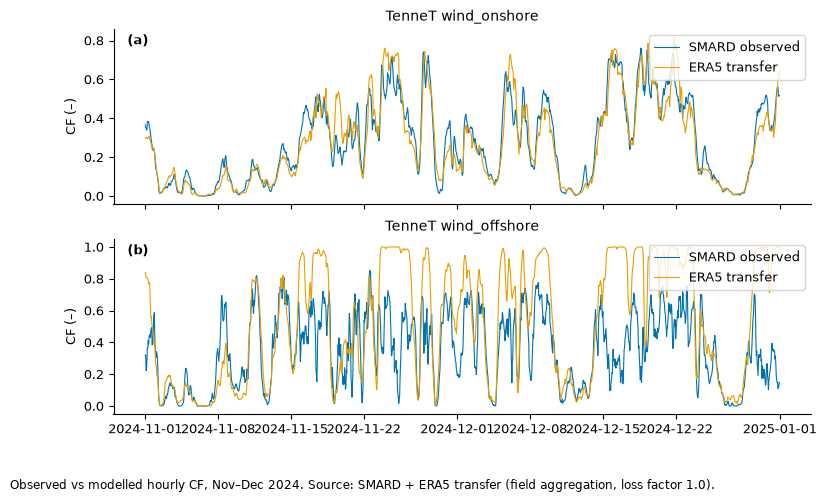

In [7]:
# Purpose: observed vs modelled CF time series — one onshore + one offshore zone.
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
w = "Nov-Dec 2024"
gen, cap = obs[w]
for ax, (zone, var) in zip(axes, [("TenneT", "wind_onshore"), ("TenneT", "wind_offshore")], strict=True):
    o = (
        gen.filter(pl.col("zone") == zone, pl.col("variable") == var)
        .join(
            cap.filter(pl.col("zone") == zone, pl.col("variable") == var).rename({"value_mw": "c"}),
            on=["time", "zone"],
        )
        .with_columns((pl.col("value_mw") / pl.col("c")).alias("cf"))
    )
    m_ = modelled[(w, zone, var)]
    ax.plot(o["time"].to_numpy(), o["cf"].to_numpy(), lw=0.8, label="SMARD observed")
    ax.plot(m_["time"].to_numpy(), m_["cf_model"].to_numpy(), lw=0.8, label="ERA5 transfer")
    ax.set_ylabel("CF (–)")
    ax.legend(loc="upper right")
    ax.set_title(f"{zone} {var}")
plotting.label_panels(axes)
plotting.caption(
    fig,
    "Observed vs modelled hourly CF, Nov–Dec 2024. Source: SMARD + ERA5 transfer "
    "(field aggregation, loss factor 1.0).",
)
plt.show()

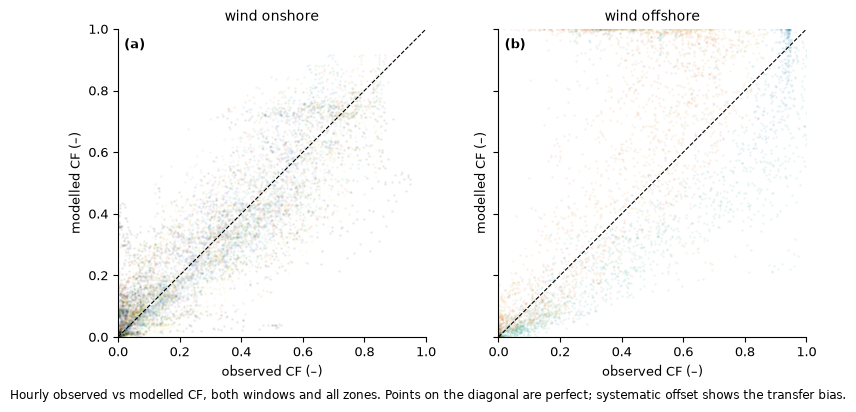

In [8]:
# Purpose: observed-vs-modelled scatter, one panel per technology.
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, var in zip(axes, ["wind_onshore", "wind_offshore"], strict=True):
    for w in WINDOWS:
        gen, cap = obs[w]
        for zone in ZONES:
            if (w, zone, var) not in modelled:
                continue
            o = (
                gen.filter(pl.col("zone") == zone, pl.col("variable") == var)
                .join(
                    cap.filter(pl.col("zone") == zone, pl.col("variable") == var).rename({"value_mw": "c"}),
                    on=["time", "zone"],
                )
                .with_columns((pl.col("value_mw") / pl.col("c")).alias("cf"))
            )
            j = o.join(modelled[(w, zone, var)].select("time", "cf_model"), on="time")
            ax.scatter(j["cf"], j["cf_model"], s=1, alpha=0.05)
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(var.replace("wind_", "wind "))
    ax.set_xlabel("observed CF (–)")
    ax.set_ylabel("modelled CF (–)")
    ax.set_aspect("equal")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
plotting.label_panels(axes)
plotting.caption(
    fig,
    "Hourly observed vs modelled CF, both windows and all zones. Points on the "
    "diagonal are perfect; systematic offset shows the transfer bias.",
)
plt.show()

## Limitations and next step

- Fleet boxes are static proxies; onshore uses *one* Germany box, so all four
  zones share the same modelled onshore CF — per-zone differences are purely
  observational. MaStR-weighted footprints are the planned fix.
- The power curve is one generic IEC class; wake/availability/curtailment sit
  in `loss_factor`, reported at 1.0/0.88 — never fitted to SMARD.
- Validation covers two months only; seasonal generality is unproven.
- **Next:** notebook 03 measures atmospheric blocking; notebook 04 then asks
  whether modelled Dunkelfläute coincide with observed ones.